In [2]:
# !pip install --upgrade openpyxl
import pandas as pd
raw_data = pd.read_excel('Rawdata.xlsx')
raw_data.head()

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year


In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       4 non-null      str  
 3   Location  4 non-null      str  
 4   Salary    6 non-null      str  
 5   Exp       5 non-null      str  
dtypes: str(6)
memory usage: 619.0 bytes


In [4]:
raw_data.describe()

,Name,Domain,Age,Location,Salary,Exp
count,6,6,4,4,6,5
unique,6,6,4,4,6,5
top,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
freq,1,1,1,1,1,1


In [5]:
raw_data.shape

(6, 6)

In [6]:
id(raw_data)

13337449552

In [7]:
raw_data.columns

Index(['Name', 'Domain', 'Age', 'Location', 'Salary', 'Exp'], dtype='str')

### Check for missing values

In [8]:
raw_data.isnull()

,Name,Domain,Age,Location,Salary,Exp
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,False,False,True,False,False,True
4,False,False,False,True,False,False
5,False,False,False,False,False,False


In [9]:
raw_data.isnull().sum()

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

In [10]:
raw_data.isna()

,Name,Domain,Age,Location,Salary,Exp
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,False,False,True,False,False,True
4,False,False,False,True,False,False
5,False,False,False,False,False,False


In [11]:
raw_data.isna().sum()

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

In [12]:
raw_data.dtypes

Name        str
Domain      str
Age         str
Location    str
Salary      str
Exp         str
dtype: object

In [13]:
pd.__version__

'3.0.3'

### Clean Data

In [20]:
raw_data['Name'] = raw_data['Name'].str.replace('\W','',regex=True)
raw_data['Domain'] = raw_data['Domain'].str.replace('\W','',regex=True)
raw_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [14]:
raw_data['Age'] = raw_data['Age'].str.extract('(\d+)')
raw_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34,Mumbai,5^00#0,2+
1,Teddy^,Testing,45,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67,NaN,30000-,5+ year
5,Kim,NLP,55,Delhi,6000^$0,10+


In [17]:
raw_data['Salary'] = raw_data['Salary'].str.replace('\W','',regex=True)
raw_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34,Mumbai,5000,2+
1,Teddy^,Testing,45,Bangalore,10000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,15000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,20000,NaN
4,Uttam*,Statistics,67,NaN,30000,5+ year
5,Kim,NLP,55,Delhi,60000,10+


In [19]:
raw_data['Exp'] = raw_data['Exp'].str.extract('(\d+)')
raw_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34,Mumbai,5000,2
1,Teddy^,Testing,45,Bangalore,10000,3
2,Uma#r,Dataanalyst^^#,NaN,NaN,15000,4
3,Jane,Ana^^lytics,NaN,Hyderbad,20000,NaN
4,Uttam*,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [40]:
clean_data = raw_data.copy()
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


### EDA Techniques

#### 1. Fill missing values (MISSING VALUE TREATMENT)

In [41]:
clean_data.isnull().sum()

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

In [42]:
clean_data['Age'].isnull()

0    False
1    False
2     True
3     True
4    False
5    False
Name: Age, dtype: bool

In [43]:
import numpy as np
clean_data['Age'] = clean_data['Age'].fillna(np.mean(pd.to_numeric(clean_data['Age'])))
clean_data['Age']

0       34
1       45
2    50.25
3    50.25
4       67
5       55
Name: Age, dtype: object

In [44]:
clean_data['Exp'] = clean_data['Exp'].fillna(np.mean(pd.to_numeric(clean_data['Exp'])))
clean_data['Exp']

0      2
1      3
2      4
3    4.8
4      5
5     10
Name: Exp, dtype: object

In [45]:
clean_data['Location'] = clean_data['Location'].fillna(clean_data['Location'].mode()[0])
clean_data['Location']

0       Mumbai
1    Bangalore
2    Bangalore
3     Hyderbad
4    Bangalore
5        Delhi
Name: Location, dtype: str

In [47]:
raw_data['Location'].mode()[0]

'Bangalore'

In [48]:
id(raw_data)

13337449552

In [49]:
id(clean_data)

14502211280

In [50]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      str   
 1   Domain    6 non-null      str   
 2   Age       6 non-null      object
 3   Location  6 non-null      str   
 4   Salary    6 non-null      str   
 5   Exp       6 non-null      object
dtypes: object(2), str(4)
memory usage: 574.0+ bytes


In [54]:
clean_data['Name'] = clean_data['Name'].astype('category')
clean_data['Domain'] = clean_data['Domain'].astype('category')
clean_data['Location'] = clean_data['Domain'].astype('category')
clean_data['Age'] = clean_data['Age'].astype('float')
clean_data['Salary'] = clean_data['Salary'].astype('int')
clean_data['Exp'] = clean_data['Exp'].astype('float')

In [55]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Name      6 non-null      category
 1   Domain    6 non-null      category
 2   Age       6 non-null      float64 
 3   Location  6 non-null      category
 4   Salary    6 non-null      int64   
 5   Exp       6 non-null      float64 
dtypes: category(3), float64(2), int64(1)
memory usage: 568.0 bytes


In [56]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34.00,Datascience,5000,2.0
1,Teddy,Testing,45.00,Testing,10000,3.0
2,Umar,Dataanalyst,50.25,Dataanalyst,15000,4.0
3,Jane,Analytics,50.25,Analytics,20000,4.8
4,Uttam,Statistics,67.00,Statistics,30000,5.0
5,Kim,NLP,55.00,NLP,60000,10.0


In [59]:
clean_data.to_csv('CleanData.csv')

In [60]:
import os
os.getcwd()

'/Users/rojarani/Documents/AIML/NIT/FSDS/Full-Stack-Data-Science-WIth-Gen-AI-and-Agentic-AI/EDA'

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

### Univariate Analysis

In [63]:
clean_data['Salary']

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

<Axes: xlabel='Salary', ylabel='Count'>

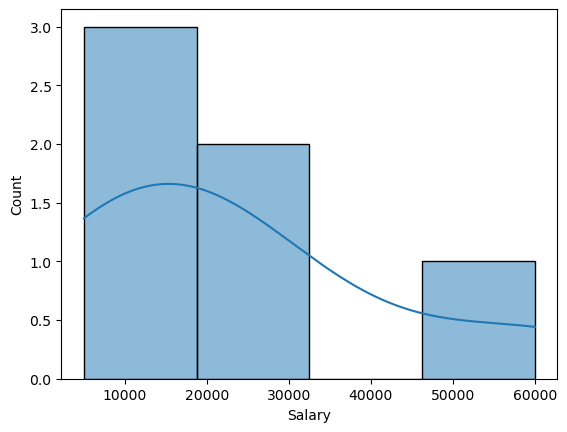

In [67]:
sns.histplot(clean_data['Salary'],kde=True)

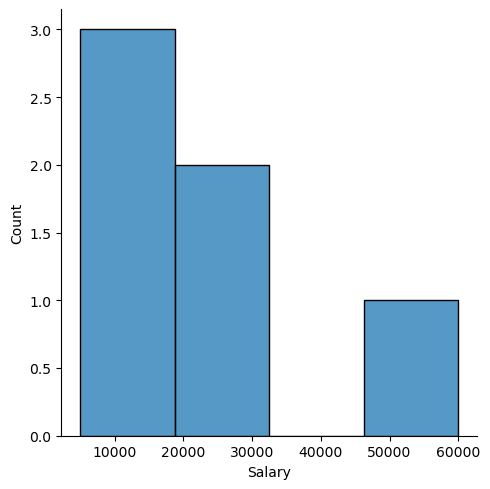

In [69]:
sns.displot(clean_data['Salary'])

(array([2., 1., 1., 0., 1., 0., 0., 0., 0., 1.]),
 array([ 5000., 10500., 16000., 21500., 27000., 32500., 38000., 43500.,
        49000., 54500., 60000.]),
 <BarContainer object of 10 artists>)

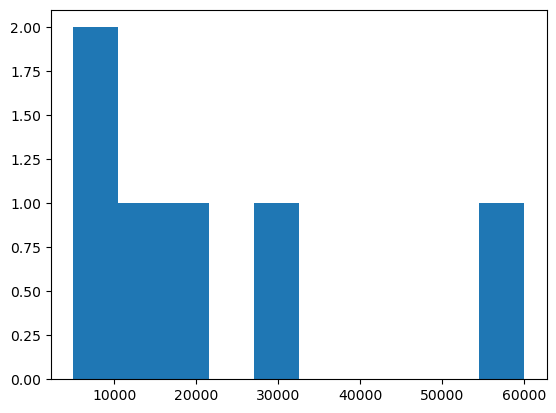

In [72]:
plt.hist(clean_data['Salary'])

### Bivariate Analysis

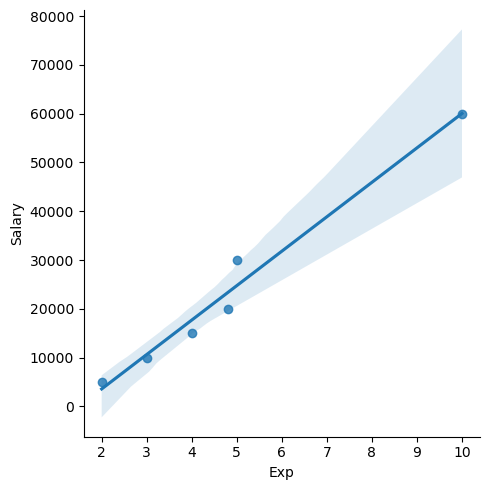

In [73]:
sns.lmplot(data=clean_data,x='Exp',y='Salary')

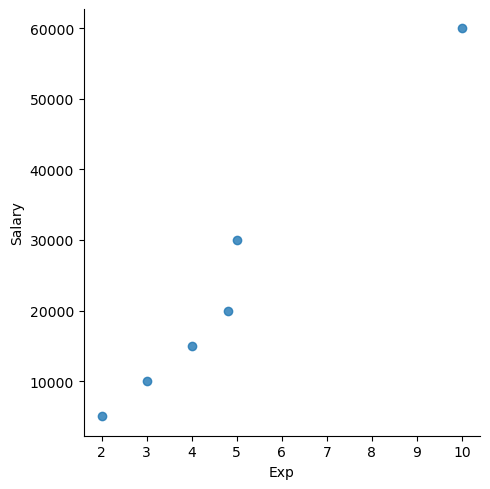

In [74]:
sns.lmplot(data=clean_data,x='Exp',y='Salary',fit_reg=False)

In [80]:
clean_data[3:4]

,Name,Domain,Age,Location,Salary,Exp
3,Jane,Analytics,50.25,Analytics,20000,4.8


### Variable Identification

In [85]:
y_dv = clean_data[['Salary']]
y_dv

,Salary
0,5000
1,10000
2,15000
3,20000
4,30000
5,60000


In [83]:
x_iv = clean_data[['Name','Domain','Age','Location','Exp']]
x_iv

,Name,Domain,Age,Location,Exp
0,Mike,Datascience,34.00,Datascience,2.0
1,Teddy,Testing,45.00,Testing,3.0
2,Umar,Dataanalyst,50.25,Dataanalyst,4.0
3,Jane,Analytics,50.25,Analytics,4.8
4,Uttam,Statistics,67.00,Statistics,5.0
5,Kim,NLP,55.00,NLP,10.0


### Imputation or Transformers

In [86]:
imputation = pd.get_dummies(clean_data)
imputation

,Age,Salary,Exp,Name_Jane,Name_Kim,Name_Mike,Name_Teddy,Name_Umar,Name_Uttam,Domain_Analytics,...,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Analytics,Location_Dataanalyst,Location_Datascience,Location_NLP,Location_Statistics,Location_Testing
0,34.00,5000,2.0,False,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,45.00,10000,3.0,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,50.25,15000,4.0,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,50.25,20000,4.8,True,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,67.00,30000,5.0,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
5,55.00,60000,10.0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [87]:
imputation1 = pd.get_dummies(clean_data, dtype=int)
imputation1

,Age,Salary,Exp,Name_Jane,Name_Kim,Name_Mike,Name_Teddy,Name_Umar,Name_Uttam,Domain_Analytics,...,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Analytics,Location_Dataanalyst,Location_Datascience,Location_NLP,Location_Statistics,Location_Testing
0,34.00,5000,2.0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1,45.00,10000,3.0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,50.25,15000,4.0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,50.25,20000,4.8,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,67.00,30000,5.0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
5,55.00,60000,10.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
